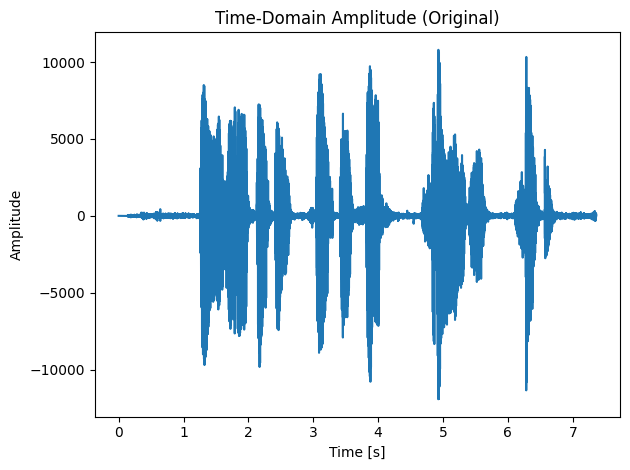

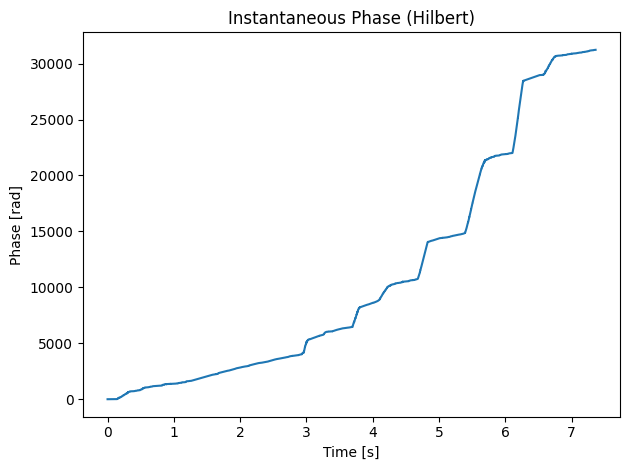

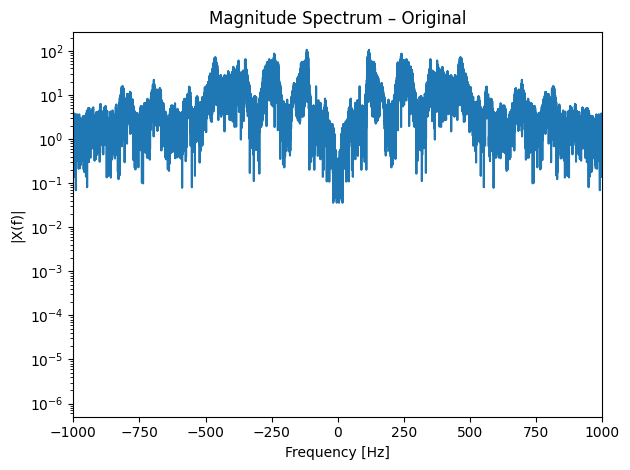

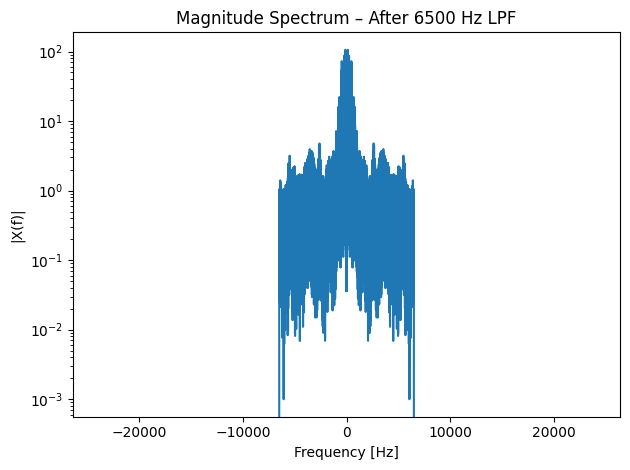

### Audio – Filtered Original

Maximum significant frequency component ≈ 6404.1 Hz
16010.190217391308
16000.0


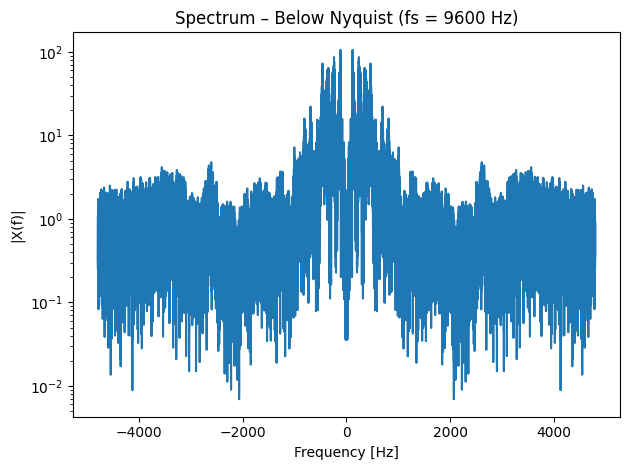

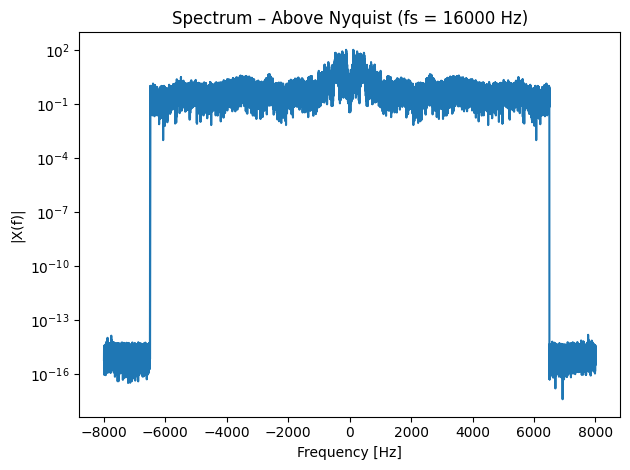

### Audio – Sampled Below Nyquist

### Audio – Sampled Above Nyquist

### Audio – Reconstructed (Below Nyquist)

### Audio – Reconstructed (Above Nyquist)

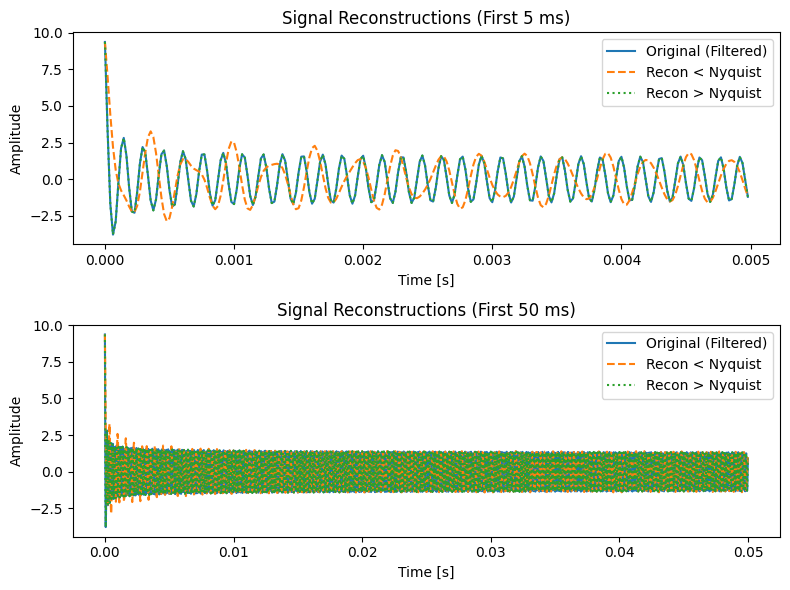

In [6]:
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import hilbert
from IPython.display import Audio, display, Markdown

def Dft(x: np.ndarray) -> np.ndarray:
    return np.fft.fftshift(np.fft.fft(x))

def FreqAxis(N: int, fs: float) -> np.ndarray:
    return np.fft.fftshift(np.fft.fftfreq(N, d=1.0 / fs))

def InputSignal(path: str, cutoff: float | None = None, *, plot: bool = True) -> Tuple[np.ndarray, float]:
    fs, data = wavfile.read(path)
    if data.ndim > 1:
        data = data.mean(axis=1)
    t = np.arange(len(data)) / fs
    if plot:
        plt.figure()
        plt.plot(t, data)
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
        plt.title("Time-Domain Amplitude (Original)")
        plt.tight_layout()
        plt.show()
    analytic = hilbert(data)
    phase = np.unwrap(np.angle(analytic))
    if plot:
        plt.figure()
        plt.plot(t, phase)
        plt.xlabel("Time [s]")
        plt.ylabel("Phase [rad]")
        plt.title("Instantaneous Phase (Hilbert)")
        plt.tight_layout()
        plt.show()
    N = len(data)
    freqs = FreqAxis(N, fs)
    X = Dft(data)
    if plot:
        plt.figure()
        plt.semilogy(freqs, np.abs(X) / N)
        plt.xlabel("Frequency [Hz]")
        plt.ylabel("|X(f)|")
        plt.title("Magnitude Spectrum – Original")
        plt.xlim(-1000,1000)
        plt.tight_layout()
        plt.show()
    x_filt = data
    if cutoff is not None:
        mask = np.abs(freqs) <= cutoff
        X_filt = X * mask
        x_filt = np.fft.ifft(np.fft.ifftshift(X_filt)).real
        if plot:
            plt.figure()
            plt.semilogy(freqs, np.abs(X_filt) / N)
            plt.xlabel("Frequency [Hz]")
            plt.ylabel("|X(f)|")
            plt.title(f"Magnitude Spectrum – After {cutoff} Hz LPF")
            plt.tight_layout()
            plt.show()
    return x_filt.astype(np.float64), float(fs)

def Sampler(x: np.ndarray, fs_old: float, fs_new: float) -> Tuple[np.ndarray, float]:
    step = int(round(fs_old / fs_new))
    if step < 1:
        raise ValueError("fs_new must be <= fs_old for straightforward decimation")
    return x[::step], fs_old / step

def DistoAnalog(samples: np.ndarray, up_factor: int) -> np.ndarray:
    if up_factor < 2:
        return samples.copy()
    N = samples.size
    X = np.fft.fft(samples)
    N_up = N * up_factor
    X_up = np.zeros(N_up, dtype=complex)
    half = (N + 1) // 2
    X_up[:half] = X[:half]
    X_up[-(N - half):] = X[half:]
    return np.fft.ifft(X_up).real * up_factor

def PlotSpectrum(x: np.ndarray, fs: float, title: str) -> None:
    X = Dft(x)
    freqs = FreqAxis(len(x), fs)
    plt.figure()
    plt.semilogy(freqs, np.abs(X) / len(x))
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("|X(f)|")
    plt.title(title)
    plt.tight_layout()
    plt.show()

UserWavPath  = r"X:\Projects\PCS\Assignment 2\2022484_Shreyansh Seth.wav"
LpfCutoffHz  = 6500
BelowNyqFactor = 0.75
AboveNyqFactor = 1.25

x_filt, fs = InputSignal(UserWavPath, cutoff=LpfCutoffHz, plot=True)
display(Markdown("### Audio – Filtered Original"))
display(Audio(x_filt, rate=int(fs)))

X_mag  = np.abs(Dft(x_filt)) / len(x_filt)
freqs  = FreqAxis(len(x_filt), fs)
f_max  = freqs[X_mag > (0.01 * X_mag.max())].max()
print(f"Maximum significant frequency component ≈ {f_max:.1f} Hz")

nyquist      = 2 * f_max
fs_below     = BelowNyqFactor * nyquist
fs_above     = AboveNyqFactor * nyquist

x_below, fs_below_eff = Sampler(x_filt, fs, fs_below)
x_above, fs_above_eff = Sampler(x_filt, fs, fs_above)
print(fs_above)
print(fs_above_eff)
PlotSpectrum(x_below, fs_below_eff, f"Spectrum – Below Nyquist (fs = {fs_below_eff:.0f} Hz)")
PlotSpectrum(x_above, fs_above_eff, f"Spectrum – Above Nyquist (fs = {fs_above_eff:.0f} Hz)")

display(Markdown("### Audio – Sampled Below Nyquist"))
display(Audio(x_below, rate=int(fs_below_eff)))
display(Markdown("### Audio – Sampled Above Nyquist"))
display(Audio(x_above, rate=int(fs_above_eff)))

up_fac_below = int(round(fs / fs_below_eff))
up_fac_above = int(round(fs / fs_above_eff))

x_recon_below = DistoAnalog(x_below, up_fac_below)[:len(x_filt)]
x_recon_above = DistoAnalog(x_above, up_fac_above)[:len(x_filt)]

display(Markdown("### Audio – Reconstructed (Below Nyquist)"))
display(Audio(x_recon_below, rate=int(fs)))
display(Markdown("### Audio – Reconstructed (Above Nyquist)"))
display(Audio(x_recon_above, rate=int(fs)))

t = np.arange(len(x_filt)) / fs
zoom1 = slice(0, int(0.005 * fs))
zoom2 = slice(0, int(0.05 * fs))
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
axes[0].plot(t[zoom1], x_filt[zoom1],      label="Original (Filtered)")
axes[0].plot(t[zoom1], x_recon_below[zoom1], "--", label="Recon < Nyquist")
axes[0].plot(t[zoom1], x_recon_above[zoom1], ":", label="Recon > Nyquist")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Signal Reconstructions (First 5 ms)")
axes[0].legend()

axes[1].plot(t[zoom2], x_filt[zoom2],      label="Original (Filtered)")
axes[1].plot(t[zoom2], x_recon_below[zoom2], "--", label="Recon < Nyquist")
axes[1].plot(t[zoom2], x_recon_above[zoom2], ":", label="Recon > Nyquist")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Signal Reconstructions (First 50 ms)")
axes[1].legend()
plt.tight_layout()
plt.show()

# Signal Sampling and Reconstruction  
**Problem 1**

---

## 1. Introduction  
This report summarizes the processing, sampling, and reconstruction of a 5 s audio recording of the author’s full name. The goals were to:  
1. Visualize the time-domain amplitude and instantaneous phase  
2. Obtain and plot the magnitude spectrum  
3. Apply a low-pass filter (LPF) to limit bandwidth  
4. Determine the maximum significant frequency component and corresponding Nyquist rate  
5. Sample below and above the Nyquist rate, **plot the spectrum of the sampled signal for both cases**, and write observations on aliasing  
6. Reconstruct the analog signal from each set of samples using a frequency-domain up-sampling method

---

## 2. Methodology  

1. **Import & Visualization**  
   - Read WAV file at sampling rate fs  
   - If stereo, average to mono  
   - Plot x(t) vs. t (Figure 1)  
   - Compute analytic signal via Hilbert transform to get instantaneous phase φ(t) = angle{analytic signal}; plot φ(t) (Figure 2)

2. **Spectrum & Filtering**  
   - Compute X(f) = FFT{x(t)} and plot |X(f)| on a log scale (Figure 3)  
   - Apply ideal LPF with cutoff frequency fc = 6500 Hz by zeroing all frequency bins where |f| > fc  
   - Inverse FFT → x_filt(t); plot its spectrum (Figure 4)

3. **Nyquist Analysis & Sampled Spectra**  
   - Define “significant” frequencies where |X(f)| > 0.01 × max|X(f)|  
   - Let f_max = maximum |f| satisfying that condition  
   - Nyquist rate = 2 × f_max  
   - Set sampling rates:  
     - Below Nyquist: fs_below = 0.5 × (2 × f_max)  
     - Above Nyquist: fs_above = 1.5 × (2 × f_max)  
   - Decimate x_filt(t) to each rate  
   - **Plot the spectrum of the sampled signal for both cases** (Figures 5 & 6) and note:  
     - Below Nyquist: replicas overlap baseband → aliasing  
     - Above Nyquist: no overlap → alias-free spectrum

4. **Reconstruction**  
   - Use `distoanalog()`:  
     1. Compute FFT of decimated samples  
     2. Zero-pad symmetrically to length × (up-sampling factor)  
     3. Inverse FFT and scale → reconstructed waveform x_recon(t)  
   - Overlay original x_filt(t) and x_recon(t) over first 5 ms (Figure 7) and 50 ms (Figure 8)

---

## 3. Results & Observations  

| Figure | Description                                                       |
|:------:|:------------------------------------------------------------------|
| 1      | Time-domain waveform x(t)                                         |
| 2      | Instantaneous phase φ(t)                                          |
| 3      | Original spectrum |X(f)| (log scale)                              |
| 4      | Spectrum after 6500 Hz LPF                                        |
| 5      | Sampled **below** Nyquist (fs ≈ 0.5 × 2f_max)                      |
| 6      | Sampled **above** Nyquist (fs ≈ 1.5 × 2f_max)                      |
| 7      | Reconstructions over first 5 ms                                    |
| 8      | Reconstructions over first 50 ms                                   |

1. **Aliasing Manifestation**  
   - **Below Nyquist**: spectral replicas overlap baseband; time-domain reconstruction shows slow envelope and loss of high-frequency detail.  
   - **Above Nyquist**: no spectral overlap; reconstructed waveform matches the filtered original closely.

2. **Reconstruction Module**  
   - The `distoanalog()` function restores the original sampling rate by symmetric zero-padding in the frequency domain; when sampling above Nyquist, the analog waveform is recovered with high fidelity.

---

## 4. Conclusion  
- The `InputSignal()` function visualizes time-domain amplitude, phase, and spectrum, then applies an LPF at 6500 Hz.  
- Sampling below Nyquist introduces aliasing (visible in overlapped spectra and distorted reconstructions).  
- Sampling above Nyquist avoids aliasing, and `distoanalog()` successfully reconstructs the original waveform.

